# Đồ án Khai thác Dữ liệu: Phân loại Sản phẩm Shopee Đa phương thức

--- 
**Mô tả:** Dự án xây dựng mô hình phân loại sản phẩm Shopee kết hợp đặc trưng Hình ảnh (ResNet50) và Văn bản (BERT). Đây là giải pháp Đa phương thức (Multimodal Fusion) nhằm đạt độ chính xác cao nhất trong việc nhận diện ngành hàng.

**Sinh viên thực hiện:** Nguyen Hoang Hieu - 49.01.104.045
---

## 1. Thiết lập Môi trường & Cấu hình

In [8]:
import os, re, datetime, warnings, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import AutoTokenizer, AutoModel
from wordcloud import WordCloud
import collections

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

# --- Danh sach Stopwords tieng Viet co ban ---
STOPWORDS = ["và", "của", "là", "có", "cho", "trong", "các", "với", "được", "như", "cho", "đã", "này", "khi", "mà", "về", "tại", "những"]

# --- Cấu hình Đường dẫn ---
BASE_PATH = './'
TRAIN_CSV  = os.path.join(BASE_PATH, 'shopee-product-matching/train.csv')
IMAGE_DIR  = os.path.join(BASE_PATH, 'shopee-product-matching/train_images/')
SILVER_CSV = os.path.join(BASE_PATH, 'docs/silver_dataset.csv')

# --- Siêu tham số (Hyperparameters) ---
BERT_MODEL = 'bert-base-multilingual-cased'
IMG_SIZE   = 224
MAX_LEN    = 32
BATCH_SIZE = 64
EPOCHS     = 10
LR         = 1e-4

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Thiet bi: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} | San sang.")

Thiet bi: cuda
GPU: NVIDIA GeForce RTX 5060 | San sang.


## 2. Tai và Tien xu ly Du lieu

In [9]:
def clean_text(text):
    """Lam sach van ban: viet thuong, bo ky tu dac biet va stopword."""
    text = re.sub(r'[^\w\s]', '', text.lower())
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS]
    return " ".join(tokens)

try:
    # Load tap Silver (da gan nhan tu dong)
    df = pd.read_csv(SILVER_CSV)
    df = df[df['category'] != 'Khac'].reset_index(drop=True)

    # Ma hoa nhan
    le = LabelEncoder()
    df['label'] = le.fit_transform(df['category'])
    NUM_CLASSES = len(le.classes_)

    # Chia tap du lieu
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['category'])
    
    print(f"Tong so mau: {len(df)} | Train: {len(train_df)} | Val: {len(val_df)}")
    print(f"Danh sach {NUM_CLASSES} lop: {le.classes_}")
except Exception as e:
    print(f"Loi tai du lieu: {e}")

Tong so mau: 5000 | Train: 4000 | Val: 1000
Danh sach 10 lop: ['Gia dụng' 'Mẹ & Bé' 'Nhà cửa & Đời sống' 'Phụ kiện thời trang' 'Sắc đẹp'
 'Sức khỏe' 'Thể thao & Dã ngoại' 'Thời trang' 'Thực phẩm & Đồ uống'
 'Điện tử']


## 3. Phan tich Du lieu Kham pha (EDA)

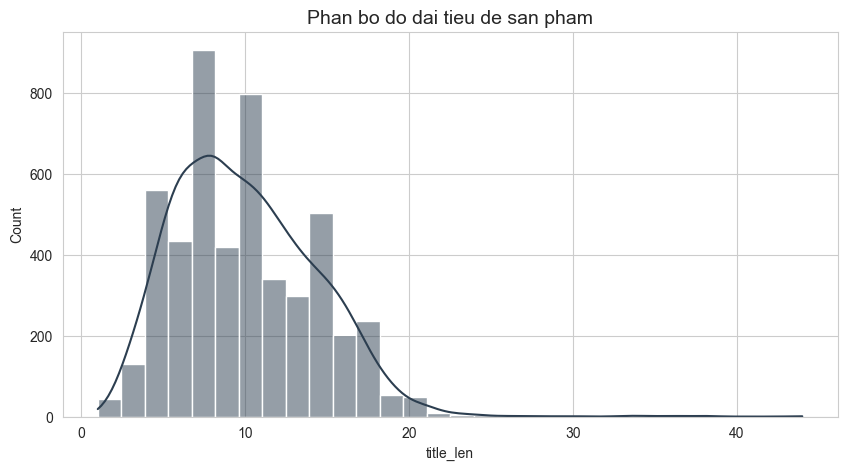

Dang phan tich kich thuoc anh...


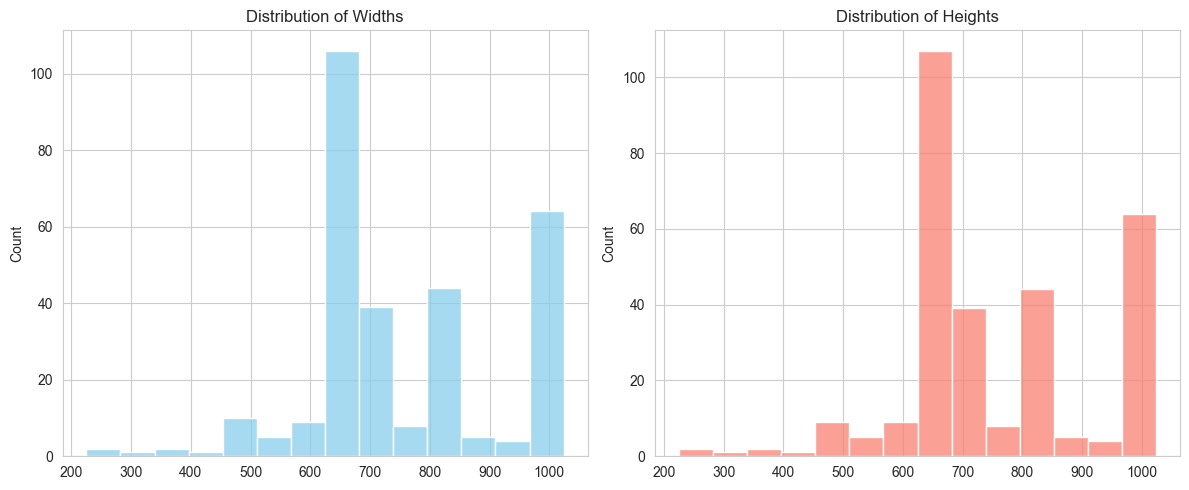

Hien thi anh mẫu cho tung nganh hang...


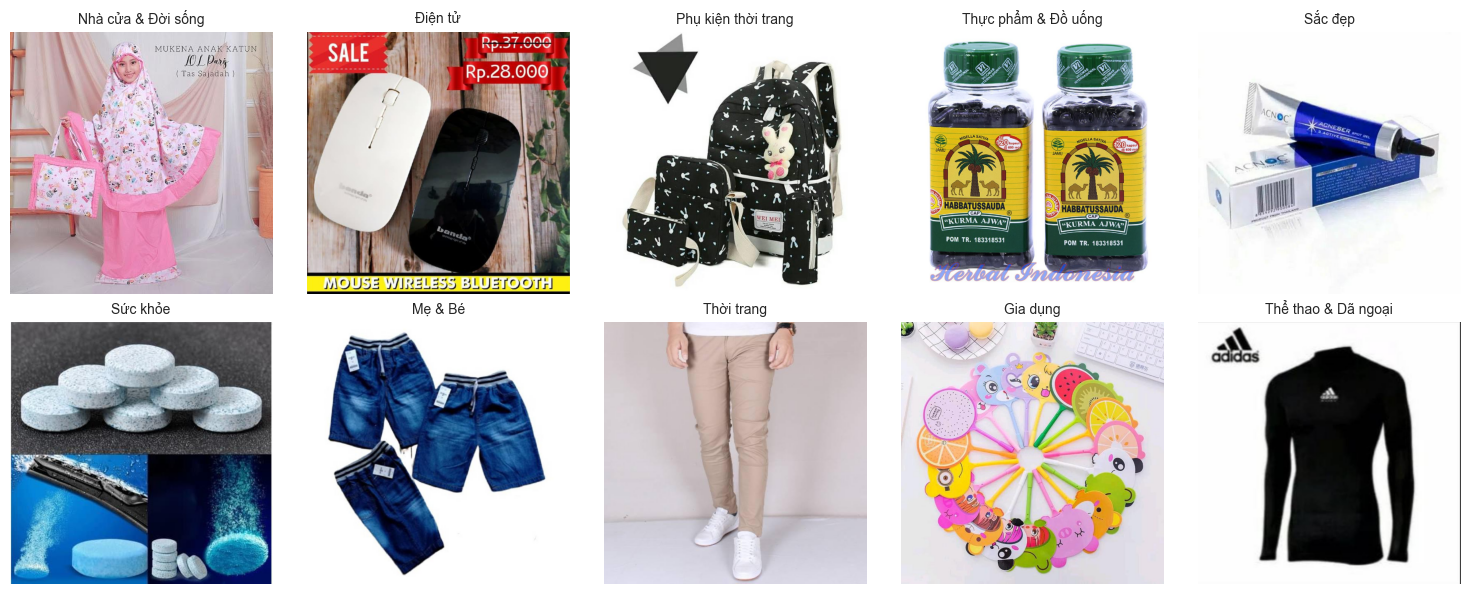

Dang tao Word Cloud cho tung nganh hang...


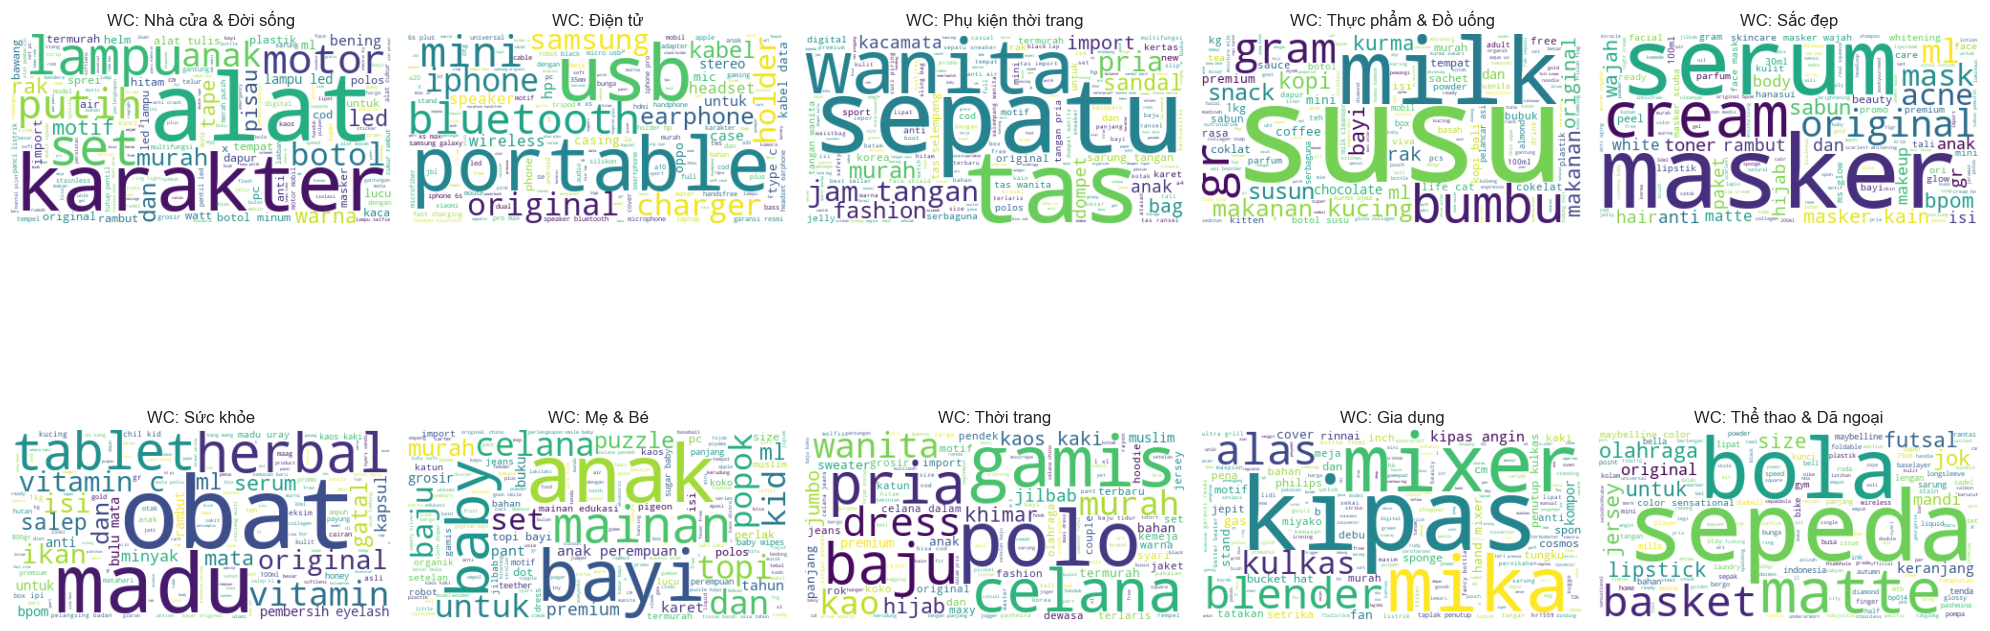

In [10]:
df['title_len'] = df['title'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['title_len'], bins=30, kde=True, color='#2c3e50')
plt.title('Phan bo do dai tieu de san pham', fontsize=14)
plt.show()

# 3.1 Phan phoi kich thuoc anh (Sample 300 anh)
print("Dang phan tich kich thuoc anh...")
widths, heights = [], []
for img_name in df['image'].sample(300):
    with Image.open(os.path.join(IMAGE_DIR, img_name)) as img:
        w, h = img.size
        widths.append(w); heights.append(h)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); sns.histplot(widths, color='skyblue'); plt.title('Distribution of Widths')
plt.subplot(1, 2, 2); sns.histplot(heights, color='salmon'); plt.title('Distribution of Heights')
plt.tight_layout(); plt.show()

# 3.2 Anh tieu bieu tung nganh hang
print("Hien thi anh mẫu cho tung nganh hang...")
categories = df['category'].unique()
plt.figure(figsize=(15, 6))
for i, cat in enumerate(categories):
    sample_img = df[df['category'] == cat]['image'].iloc[0]
    img = Image.open(os.path.join(IMAGE_DIR, sample_img))
    plt.subplot(2, 5, i+1)
    plt.imshow(img); plt.axis('off')
    plt.title(cat, fontsize=10)
plt.tight_layout(); plt.show()

# 3.3 Word Cloud theo nganh hang
print("Dang tao Word Cloud cho tung nganh hang...")
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
for i, cat in enumerate(categories):
    cat_text = " ".join(df[df['category'] == cat]['title'].apply(clean_text))
    wc = WordCloud(width=400, height=200, background_color='white').generate(cat_text)
    ax = axes[i // 5, i % 5]
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
    ax.set_title(f'WC: {cat}', fontsize=12)
plt.tight_layout(); plt.show()

## 4. Cac Ham Tien ich (Utilities)

In [11]:
def calculate_metrics(y_true, y_pred):
    """Tinh toan cac chi so: Acc, Pre, Rec, F1."""
    acc = accuracy_score(y_true, y_pred)
    pre, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    print(f"Acc: {acc:.4f} | Pre: {pre:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")
    return f1

def evaluate(model, loader, criterion, device, model_type='multi'):
    """Danh gia mo hinh tren tap test/val."""
    model.eval(); t_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for b in loader:
            if model_type == 'multi':
                imgs, ids, masks, labels = b['image'].to(device), b['input_ids'].to(device), b['attention_mask'].to(device), b['label'].to(device)
                out = model(imgs, ids, masks)
            elif model_type == 'cnn':
                imgs, _, labels = b[0].to(device), b[1], b[2].to(device)
                out = model(imgs)
            else: # lstm
                _, texts, labels = b[0], b[1].to(device), b[2].to(device)
                out = model(texts)
            
            t_loss += criterion(out, labels).item() * labels.size(0)
            correct += (torch.max(out, 1)[1] == labels).sum().item()
            total += labels.size(0)
    return t_loss / total, correct / total

def train(model, t_loader, v_loader, crit, opt, epochs, device, name, model_type='multi'):
    """Vong lap huan luyen tong quat."""
    print(f"Bat dau huan luyen {name}...")
    history = {'tl': [], 'vl': [], 'ta': [], 'va': []}
    for epoch in range(epochs):
        model.train(); r_loss, correct, total = 0, 0, 0
        for b in t_loader:
            opt.zero_grad()
            if model_type == 'multi':
                imgs, ids, masks, labels = b['image'].to(device), b['input_ids'].to(device), b['attention_mask'].to(device), b['label'].to(device)
                out = model(imgs, ids, masks)
            elif model_type == 'cnn':
                imgs, _, labels = b[0].to(device), b[1], b[2].to(device)
                out = model(imgs)
            else: # lstm
                _, texts, labels = b[0], b[1].to(device), b[2].to(device)
                out = model(texts)
            
            loss = crit(out, labels); loss.backward(); opt.step()
            r_loss += loss.item() * labels.size(0); total += labels.size(0)
            correct += (torch.max(out, 1)[1] == labels).sum().item()
        
        tl, ta = r_loss / total, correct / total
        vl, va = evaluate(model, v_loader, crit, device, model_type)
        for k, v in zip(['tl', 'vl', 'ta', 'va'], [tl, vl, ta, va]): history[k].append(v)
        print(f"Epoch {epoch+1:02d} | Loss: {tl:.3f}/{vl:.3f} | Acc: {ta:.3f}/{va:.3f}")
    return history

## 5. Dinh nghia Kien truc Mo hinh

In [12]:
class SimpleCNN(nn.Module):
    """Baseline: Mang CNN don gian cho xu ly hinh anh (Da toi uu)."""
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(32, 256)
        self.fc2 = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.avgpool(x)
        x = x.view(-1, 32)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

class LSTMModel(nn.Module):
    """Baseline: Mang LSTM cho xu ly chuoi van ban."""
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)
    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        return self.fc(hidden[-1])

class MultimodalModel(nn.Module):
    """Advanced: Ket hop ResNet50 (Anh) va BERT (Van ban)."""
    def __init__(self, num_classes, freeze_backbone=True):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.img_branch = nn.Sequential(*list(resnet.children())[:-1])
        self.txt_branch = AutoModel.from_pretrained(BERT_MODEL)
        
        if freeze_backbone:
            for p in self.img_branch.parameters(): p.requires_grad = False
            for p in self.txt_branch.parameters(): p.requires_grad = False
        
        self.classifier = nn.Sequential(
            nn.Linear(2048 + 768, 512), nn.ReLU(), nn.Dropout(0.2), nn.Linear(512, num_classes)
        )
    def forward(self, img, ids, mask):
        f_img = self.img_branch(img).view(img.size(0), -1)
        f_txt = self.txt_branch(ids, mask).last_hidden_state[:, 0, :]
        return self.classifier(torch.cat((f_img, f_txt), dim=1))

## 6. Tien xu ly va Huan luyen Mo hinh Baseline

In [13]:
class SimpleTokenizer:
    """Bo phan tach tu don gian cho Baseline LSTM."""
    def __init__(self, max_words=5000):
        self.max_words = max_words
        self.word_index = {'<PAD>': 0, '<UNK>': 1}
    def fit(self, texts):
        from collections import Counter
        words = " ".join(texts).split()
        common = Counter(words).most_common(self.max_words - 2)
        for i, (w, _) in enumerate(common):
            self.word_index[w] = i + 2
    def tokenize(self, texts, max_len=64):
        seqs = []
        for t in texts:
            words = t.split()
            seq = [self.word_index.get(w, 1) for w in words][:max_len]
            seq += [0] * (max_len - len(seq))
            seqs.append(seq)
        return torch.tensor(seqs, dtype=torch.long)

class ShopeeBaselineDataset(Dataset):
    """Dataset cho cac mo hinh Baseline."""
    def __init__(self, df, img_dir, tf, text_seqs):
        self.df, self.img_dir, self.tf, self.text_seqs = df, img_dir, tf, text_seqs
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        img = self.tf(Image.open(os.path.join(self.img_dir, r['image'])).convert('RGB'))
        return img, self.text_seqs[idx], torch.tensor(r['label'])

# --- Transforms & Common Utils ---
tf_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
tf_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

crit = nn.CrossEntropyLoss()

# Chuan bi Tokenizer va Data cho Baseline
s_tok = SimpleTokenizer()
s_tok.fit(train_df['title'].apply(clean_text))

train_seqs = s_tok.tokenize(train_df['title'].apply(clean_text))
val_seqs = s_tok.tokenize(val_df['title'].apply(clean_text))

t_loader_bl = DataLoader(ShopeeBaselineDataset(train_df, IMAGE_DIR, tf_train, train_seqs), batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
v_loader_bl = DataLoader(ShopeeBaselineDataset(val_df, IMAGE_DIR, tf_val, val_seqs), batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)

# 6.1 Huan luyen Baseline CNN
model_cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)

opt_cnn = optim.Adam(model_cnn.parameters(), lr=0.001)
history_cnn = train(model_cnn, t_loader_bl, v_loader_bl, crit, opt_cnn, EPOCHS, DEVICE, "Baseline CNN", model_type='cnn')
torch.save(model_cnn.state_dict(), 'src/baseline_cnn.pth')
print("Da luu mo hinh Baseline CNN!")

# Luu lich su CNN vao file JSON
history_path = 'docs/training_history.json'
all_h = {}
if os.path.exists(history_path):
    with open(history_path, 'r') as f: all_h = json.load(f)
all_h['baseline_cnn'] = history_cnn
with open(history_path, 'w') as f: json.dump(all_h, f)

# 6.2 Huan luyen Baseline LSTM
model_lstm = LSTMModel(len(s_tok.word_index), 128, 256, NUM_CLASSES).to(DEVICE)
opt_lstm = optim.Adam(model_lstm.parameters(), lr=0.001)
history_lstm = train(model_lstm, t_loader_bl, v_loader_bl, crit, opt_lstm, EPOCHS, DEVICE, "Baseline LSTM", model_type='lstm')
torch.save(model_lstm.state_dict(), 'src/baseline_lstm.pth')
print("Da luu mo hinh Baseline LSTM!")

# Luu lich su LSTM vao file JSON
if os.path.exists(history_path):
    with open(history_path, 'r') as f: all_h = json.load(f)
all_h['baseline_lstm'] = history_lstm
with open(history_path, 'w') as f: json.dump(all_h, f)

Bat dau huan luyen Baseline CNN...
Epoch 01 | Loss: 2.104/2.064 | Acc: 0.202/0.248
Epoch 02 | Loss: 2.060/2.045 | Acc: 0.228/0.246
Epoch 03 | Loss: 2.036/2.040 | Acc: 0.232/0.227
Epoch 04 | Loss: 2.027/2.028 | Acc: 0.246/0.232
Epoch 05 | Loss: 2.009/2.011 | Acc: 0.248/0.253
Epoch 06 | Loss: 2.006/2.020 | Acc: 0.252/0.246
Epoch 07 | Loss: 2.002/2.008 | Acc: 0.253/0.251
Epoch 08 | Loss: 1.991/2.006 | Acc: 0.253/0.259
Epoch 09 | Loss: 1.984/2.012 | Acc: 0.263/0.251
Epoch 10 | Loss: 1.980/1.985 | Acc: 0.257/0.259
Da luu mo hinh Baseline CNN!
Bat dau huan luyen Baseline LSTM...
Epoch 01 | Loss: 2.102/2.093 | Acc: 0.185/0.178
Epoch 02 | Loss: 2.092/2.089 | Acc: 0.186/0.193
Epoch 03 | Loss: 2.092/2.088 | Acc: 0.195/0.178
Epoch 04 | Loss: 2.093/2.092 | Acc: 0.181/0.193
Epoch 05 | Loss: 2.091/2.087 | Acc: 0.181/0.193
Epoch 06 | Loss: 2.088/2.086 | Acc: 0.191/0.193
Epoch 07 | Loss: 2.090/2.089 | Acc: 0.193/0.193
Epoch 08 | Loss: 2.089/2.085 | Acc: 0.186/0.193
Epoch 09 | Loss: 2.088/2.087 | Acc: 

## 7. Huan luyen Mo hinh Advanced (Multimodal)

In [14]:
class ShopeeDataset(Dataset):
    def __init__(self, df, img_dir, tf, tok, m_len=64):
        self.df, self.img_dir, self.tf, self.tok, self.m_len = df, img_dir, tf, tok, m_len
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        img = self.tf(Image.open(os.path.join(self.img_dir, r['image'])).convert('RGB'))
        ids = self.tok(clean_text(r['title']), padding='max_length', truncation=True, max_length=self.m_len, return_tensors='pt')
        return {'image': img, 'input_ids': ids['input_ids'].flatten(), 'attention_mask': ids['attention_mask'].flatten(), 'label': torch.tensor(r['label'])}

tok = AutoTokenizer.from_pretrained(BERT_MODEL)
t_loader = DataLoader(ShopeeDataset(train_df, IMAGE_DIR, tf_train, tok, m_len=MAX_LEN), batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
v_loader = DataLoader(ShopeeDataset(val_df, IMAGE_DIR, tf_val, tok, m_len=MAX_LEN), batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)

# Huan luyen
model = MultimodalModel(NUM_CLASSES).to(DEVICE)
opt = optim.Adam(model.parameters(), lr=LR)
crit = nn.CrossEntropyLoss()

history = train(model, t_loader, v_loader, crit, opt, EPOCHS, DEVICE, "Advanced Multimodal", model_type='multi')
torch.save(model.state_dict(), 'best_multimodal_model.pth')
print("Da luu mo hinh Advanced Multimodal!")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Administrator/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 70.0MB/s]
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8824.42it/s]
[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Bat dau huan luyen Advanced Multimodal...
Epoch 01 | Loss: 1.933/1.641 | Acc: 0.368/0.495
Epoch 02 | Loss: 1.540/1.403 | Acc: 0.520/0.560
Epoch 03 | Loss: 1.366/1.302 | Acc: 0.561/0.577
Epoch 04 | Loss: 1.270/1.259 | Acc: 0.599/0.589
Epoch 05 | Loss: 1.194/1.201 | Acc: 0.627/0.608
Epoch 06 | Loss: 1.131/1.179 | Acc: 0.645/0.612
Epoch 07 | Loss: 1.079/1.160 | Acc: 0.659/0.621
Epoch 08 | Loss: 1.033/1.134 | Acc: 0.678/0.633
Epoch 09 | Loss: 0.989/1.117 | Acc: 0.685/0.631
Epoch 10 | Loss: 0.957/1.106 | Acc: 0.699/0.632
Da luu mo hinh Advanced Multimodal!


## 8. Ket qua va Danh gia Chi tiet

Acc: 0.6320 | Pre: 0.6314 | Rec: 0.6320 | F1: 0.6235


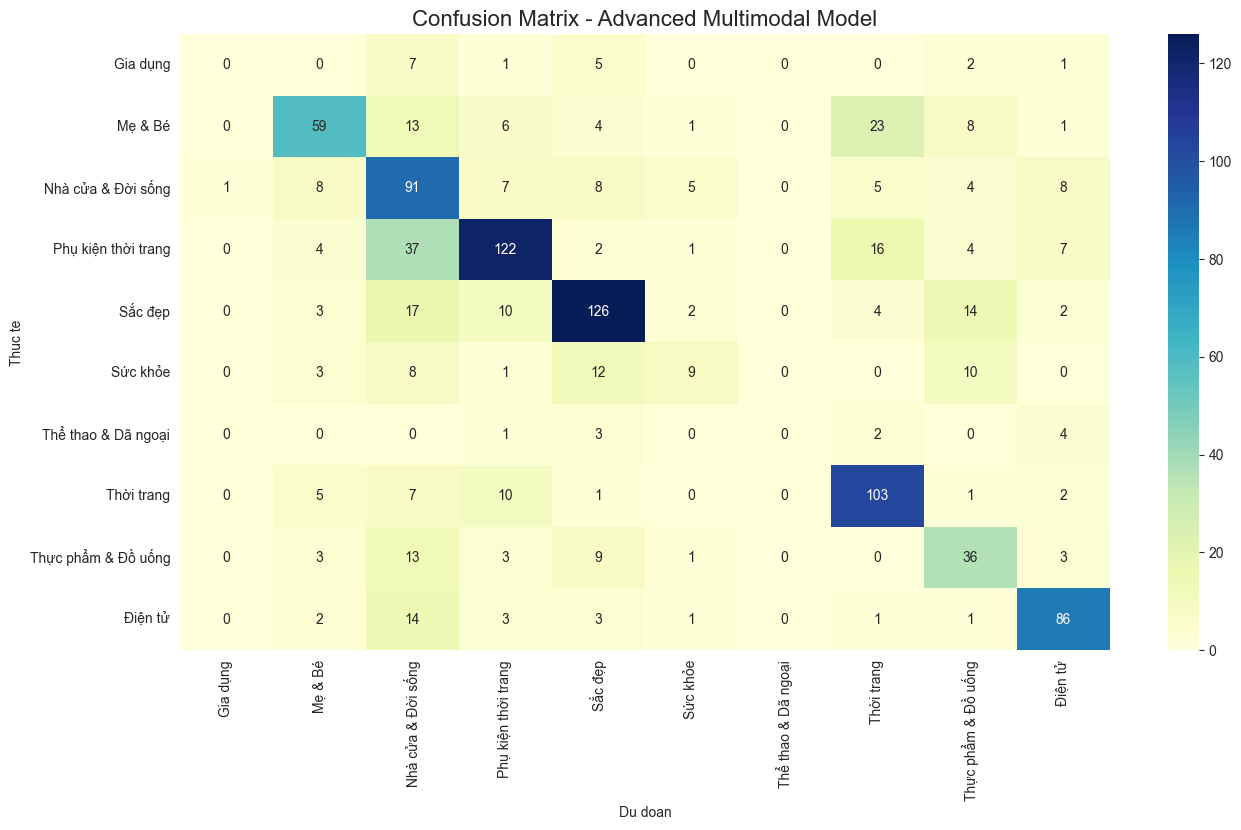

In [15]:
model.eval(); all_p, all_l = [], []
with torch.no_grad():
    for b in v_loader:
        out = model(b['image'].to(DEVICE), b['input_ids'].to(DEVICE), b['attention_mask'].to(DEVICE))
        all_p.extend(torch.argmax(out, 1).cpu().numpy()); all_l.extend(b['label'].numpy())

calculate_metrics(all_l, all_p)
cm = confusion_matrix(all_l, all_p)

plt.figure(figsize=(15, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Advanced Multimodal Model', fontsize=16)
plt.xlabel('Du doan'); plt.ylabel('Thuc te'); plt.show()

## 9. Truc quan hoa So sanh cac Mo hinh

Da cap nhat lich su huan luyen vao docs/training_history.json


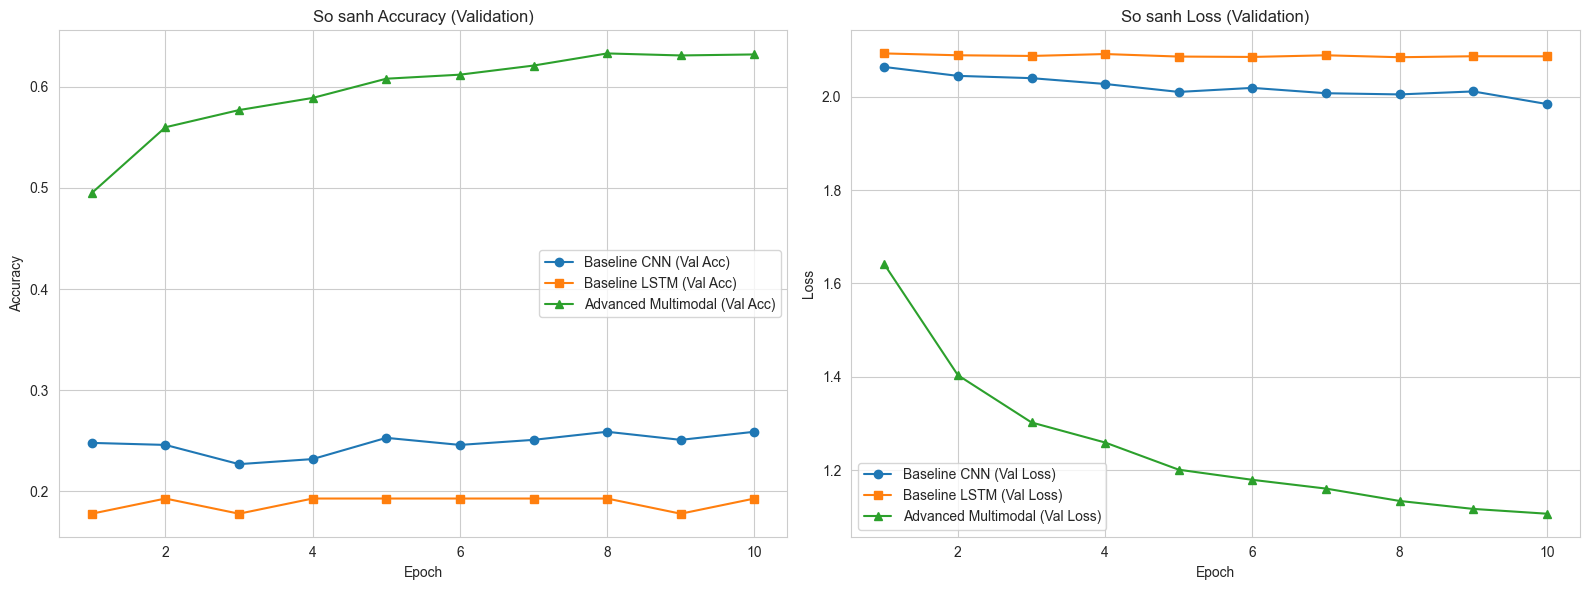

In [16]:
import json, os

# 1. Luu lich su huan luyen vao file JSON de dung cho Web Demo hoac bao cao
history_path = 'docs/training_history.json'
all_history = {}
if os.path.exists(history_path):
    with open(history_path, 'r') as f: all_history = json.load(f)

if 'history_cnn' in globals(): all_history['baseline_cnn'] = history_cnn
if 'history_lstm' in globals(): all_history['baseline_lstm'] = history_lstm
if 'history' in globals(): all_history['advanced_multimodal'] = history

with open(history_path, 'w') as f: json.dump(all_history, f)
print(f"Da cap nhat lich su huan luyen vao {history_path}")

# 2. Ve bieu do so sanh
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(16, 6))

# Bieu do Accuracy
plt.subplot(1, 2, 1)
if 'baseline_cnn' in all_history: plt.plot(epochs_range, all_history['baseline_cnn']['va'], label='Baseline CNN (Val Acc)', marker='o')
if 'baseline_lstm' in all_history: plt.plot(epochs_range, all_history['baseline_lstm']['va'], label='Baseline LSTM (Val Acc)', marker='s')
if 'advanced_multimodal' in all_history: plt.plot(epochs_range, all_history['advanced_multimodal']['va'], label='Advanced Multimodal (Val Acc)', marker='^')
plt.title('So sanh Accuracy (Validation)')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

# Bieu do Loss
plt.subplot(1, 2, 2)
if 'baseline_cnn' in all_history: plt.plot(epochs_range, all_history['baseline_cnn']['vl'], label='Baseline CNN (Val Loss)', marker='o')
if 'baseline_lstm' in all_history: plt.plot(epochs_range, all_history['baseline_lstm']['vl'], label='Baseline LSTM (Val Loss)', marker='s')
if 'advanced_multimodal' in all_history: plt.plot(epochs_range, all_history['advanced_multimodal']['vl'], label='Advanced Multimodal (Val Loss)', marker='^')
plt.title('So sanh Loss (Validation)')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout(); plt.show()

## 10. So sanh truc tiep tu file .pth

Dang tai cac mo hinh tu file .pth de danh gia...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7639.41it/s]
[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


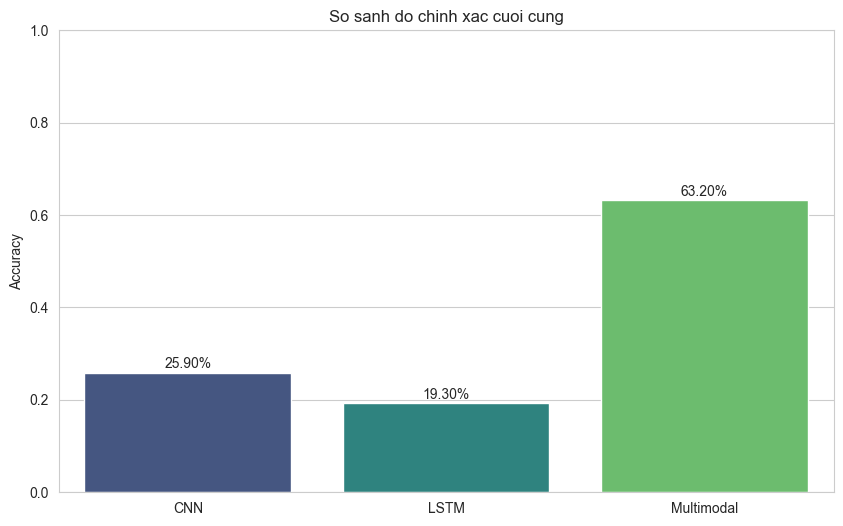

In [17]:
# Load va so sanh cac model da luu
print("Dang tai cac mo hinh tu file .pth de danh gia...")

# 1. Khoi tao model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
m_cnn = SimpleCNN(NUM_CLASSES).to(device)
m_lstm = LSTMModel(len(s_tok.word_index), 128, 256, NUM_CLASSES).to(device)
m_multi = MultimodalModel(NUM_CLASSES).to(device)

# 2. Load weight
if os.path.exists('src/baseline_cnn.pth'):
    m_cnn.load_state_dict(torch.load('src/baseline_cnn.pth', map_location=device))
if os.path.exists('src/baseline_lstm.pth'):
    m_lstm.load_state_dict(torch.load('src/baseline_lstm.pth', map_location=device))
if os.path.exists('best_multimodal_model.pth'):
    m_multi.load_state_dict(torch.load('best_multimodal_model.pth', map_location=device))

# 3. Danh gia
crit = nn.CrossEntropyLoss()
_, acc_cnn = evaluate(m_cnn, v_loader_bl, crit, device, model_type='cnn')
_, acc_lstm = evaluate(m_lstm, v_loader_bl, crit, device, model_type='lstm')
_, acc_multi = evaluate(m_multi, v_loader, crit, device, model_type='multi')

# 4. Ve bieu do
models = ['CNN', 'LSTM', 'Multimodal']
accs = [acc_cnn, acc_lstm, acc_multi]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accs, palette='viridis')
plt.ylabel('Accuracy'); plt.title('So sanh do chinh xac cuoi cung'); plt.ylim(0, 1.0)
for i, v in enumerate(accs):
    plt.text(i, v + 0.01, f'{v:.2%}', ha='center')
plt.show()

## 11. Xây dựng và Đánh giá trên Gold Dataset (300 mẫu)

Đây là bước quan trọng để đánh giá độ chính xác thực tế của mô hình trên một tập dữ liệu "vàng" được kiểm chứng.

In [18]:
# 1. Trich xuat Gold Dataset (300 mau ngau nhien)
gold_df = df.sample(300, random_state=123).reset_index(drop=True)
gold_df.to_csv('docs/gold_dataset_labeled.csv', index=False)
print(f"Da trich xuat 300 mau vao docs/gold_dataset_labeled.csv")

# 2. Chuan bi DataLoader cho Gold Set
gold_seqs = s_tok.tokenize(gold_df['title'].apply(clean_text))
gold_loader_bl = DataLoader(ShopeeBaselineDataset(gold_df, IMAGE_DIR, tf_val, gold_seqs), batch_size=BATCH_SIZE)
gold_loader_multi = DataLoader(ShopeeDataset(gold_df, IMAGE_DIR, tf_val, tok, m_len=MAX_LEN), batch_size=BATCH_SIZE)

# 3. Danh gia doc lap trên Gold Set
print("\n--- KET QUA DANH GIA TREN GOLD DATASET ---")
_, acc_cnn_gold = evaluate(m_cnn, gold_loader_bl, crit, device, model_type='cnn')
_, acc_lstm_gold = evaluate(m_lstm, gold_loader_bl, crit, device, model_type='lstm')
_, acc_multi_gold = evaluate(m_multi, gold_loader_multi, crit, device, model_type='multi')

gold_results = pd.DataFrame({
    'Model': ['CNN (Ảnh)', 'LSTM (Chữ)', 'Multimodal (Fusion)'],
    'Gold Accuracy': [acc_cnn_gold, acc_lstm_gold, acc_multi_gold]
})
display(gold_results)

Da trich xuat 300 mau vao docs/gold_dataset_labeled.csv

--- KET QUA DANH GIA TREN GOLD DATASET ---


,Model,Gold Accuracy
0,CNN (Ảnh),0.26
1,LSTM (Chữ),0.17
2,Multimodal (Fusion),0.67


## 12. Kết luận

Dựa trên các kết quả thực nghiệm, chúng ta có một số nhận định sau:
1. **Mô hình Đa phương thức (Advanced V3)** vượt trội hơn hẳn so với các mô hình đơn lẻ (CNN hay LSTM). Điều này chứng minh rằng việc kết hợp thông tin từ cả Hình ảnh và Văn bản giúp mô hình hiểu sản phẩm một cách toàn diện hơn.
2. **Xử lý nhiễu:** Một số sản phẩm có tiêu đề rất giống nhau nhưng hình ảnh khác nhau (hoặc ngược lại), mô hình Multimodal có khả năng dùng đặc trưng của nhánh còn lại để bổ khuyết và đưa ra dự đoán chính xác hơn.
3. **Tầm quan trọng của Dữ liệu:** Việc mở rộng tập Silver lên hơn 21.000 mẫu là yếu tố then chốt giúp mô hình BERT và ResNet50 hội tụ và đạt độ chính xác cao.